# Classification Plots Examples

This notebook demonstrates the usage of the ClassificationPlots class methods with sklearn datasets and models. The ClassificationPlots class provides comprehensive visualization tools for classification model evaluation including confusion matrices, probability distributions, and ROC curves.

In [1]:
import numpy as np
from sklearn.datasets import make_classification, load_iris, load_wine, load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from kvbiii_plots.evaluation.classification_plots import ClassificationPlots

/home/kvbiii/Desktop/KubiK/Programming/Python/Paczki/kvbiii-plots/kvbiii-plots_venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
class_plots = ClassificationPlots()

print("Classification Plots class initialized successfully!")
print("Available methods:")
public_methods = [
    m
    for m in dir(class_plots)
    if not m.startswith("_")
    and callable(getattr(class_plots, m))
    and m
    not in [
        "apply_default_layout",
        "add_quantile_annotations",
        "calculate_dynamic_dimensions",
        "check_2d_data",
        "check_data",
        "create_subplot_layout",
        "filter_nan_indices",
    ]
]
for method in public_methods:
    print(f"- {method}")

Classification Plots class initialized successfully!
Available methods:
- plot_confusion_matrix
- plot_f1_score_vs_threshold
- plot_precision_recall
- plot_precision_vs_recall_curve
- plot_probabilities_histogram
- plot_probabilities_per_class
- plot_roc_auc
- subplot_conf_matrix
- subplot_multilabel_conf_matrix


## Generate Sample Data and Train Models

We'll create different classification datasets and train multiple models to demonstrate various classification plotting scenarios.

In [3]:
np.random.seed(42)

X_binary, y_binary = make_classification(
    n_samples=1000, n_features=10, n_classes=2, n_informative=7, n_redundant=3, random_state=42
)
X_binary_train, X_binary_test, y_binary_train, y_binary_test = train_test_split(
    X_binary, y_binary, test_size=0.3, random_state=42
)

X_multi, y_multi = make_classification(
    n_samples=1200,
    n_features=15,
    n_classes=4,
    n_informative=10,
    n_redundant=5,
    n_clusters_per_class=1,
    random_state=42,
)
X_multi_train, X_multi_test, y_multi_train, y_multi_test = train_test_split(
    X_multi, y_multi, test_size=0.3, random_state=42
)

iris = load_iris()
X_iris, y_iris = iris.data, iris.target
X_iris_train, X_iris_test, y_iris_train, y_iris_test = train_test_split(
    X_iris, y_iris, test_size=0.3, random_state=42
)

wine = load_wine()
X_wine, y_wine = wine.data, wine.target
X_wine_train, X_wine_test, y_wine_train, y_wine_test = train_test_split(
    X_wine, y_wine, test_size=0.3, random_state=42
)

cancer = load_breast_cancer()
X_cancer, y_cancer = cancer.data, cancer.target
X_cancer_train, X_cancer_test, y_cancer_train, y_cancer_test = train_test_split(
    X_cancer, y_cancer, test_size=0.3, random_state=42
)

print("Dataset shapes:")
print(f"Binary synthetic: Train {X_binary_train.shape}, Test {X_binary_test.shape}")
print(f"Multi-class synthetic: Train {X_multi_train.shape}, Test {X_multi_test.shape}")
print(f"Iris: Train {X_iris_train.shape}, Test {X_iris_test.shape}")
print(f"Wine: Train {X_wine_train.shape}, Test {X_wine_test.shape}")
print(f"Breast Cancer: Train {X_cancer_train.shape}, Test {X_cancer_test.shape}")

Dataset shapes:
Binary synthetic: Train (700, 10), Test (300, 10)
Multi-class synthetic: Train (840, 15), Test (360, 15)
Iris: Train (105, 4), Test (45, 4)
Wine: Train (124, 13), Test (54, 13)
Breast Cancer: Train (398, 30), Test (171, 30)


In [4]:
models = {}
predictions = {}
probabilities = {}

models["rf_binary"] = RandomForestClassifier(n_estimators=100, random_state=42)
models["rf_binary"].fit(X_binary_train, y_binary_train)
predictions["rf_binary"] = models["rf_binary"].predict(X_binary_test)
probabilities["rf_binary"] = models["rf_binary"].predict_proba(X_binary_test)

models["lr_binary"] = LogisticRegression(random_state=42)
models["lr_binary"].fit(X_binary_train, y_binary_train)
predictions["lr_binary"] = models["lr_binary"].predict(X_binary_test)
probabilities["lr_binary"] = models["lr_binary"].predict_proba(X_binary_test)

models["rf_multi"] = RandomForestClassifier(n_estimators=100, random_state=42)
models["rf_multi"].fit(X_multi_train, y_multi_train)
predictions["rf_multi"] = models["rf_multi"].predict(X_multi_test)
probabilities["rf_multi"] = models["rf_multi"].predict_proba(X_multi_test)

models["gb_iris"] = GradientBoostingClassifier(n_estimators=100, random_state=42)
models["gb_iris"].fit(X_iris_train, y_iris_train)
predictions["gb_iris"] = models["gb_iris"].predict(X_iris_test)
probabilities["gb_iris"] = models["gb_iris"].predict_proba(X_iris_test)

models["svm_wine"] = SVC(probability=True, random_state=42)
models["svm_wine"].fit(X_wine_train, y_wine_train)
predictions["svm_wine"] = models["svm_wine"].predict(X_wine_test)
probabilities["svm_wine"] = models["svm_wine"].predict_proba(X_wine_test)

models["nb_cancer"] = GaussianNB()
models["nb_cancer"].fit(X_cancer_train, y_cancer_train)
predictions["nb_cancer"] = models["nb_cancer"].predict(X_cancer_test)
probabilities["nb_cancer"] = models["nb_cancer"].predict_proba(X_cancer_test)

print("Models trained and predictions generated!")
print("\nModel performance summaries:")
for name, model in models.items():
    if "binary" in name:
        y_test = y_binary_test
    elif "multi" in name:
        y_test = y_multi_test
    elif "iris" in name:
        y_test = y_iris_test
    elif "wine" in name:
        y_test = y_wine_test
    elif "cancer" in name:
        y_test = y_cancer_test

    accuracy = model.score(
        (
            X_binary_test
            if "binary" in name
            else (
                X_multi_test
                if "multi" in name
                else (
                    X_iris_test
                    if "iris" in name
                    else X_wine_test if "wine" in name else X_cancer_test
                )
            )
        ),
        y_test,
    )
    print(f"{name}: {accuracy:.3f}")

Models trained and predictions generated!

Model performance summaries:
rf_binary: 0.903
lr_binary: 0.767
rf_multi: 0.878
gb_iris: 1.000
svm_wine: 0.759
nb_cancer: 0.942


## 1. plot_confusion_matrix() - Confusion Matrix

This method creates confusion matrices comparing predictions with and without custom thresholds. It's particularly useful for understanding the impact of threshold tuning on classification performance.

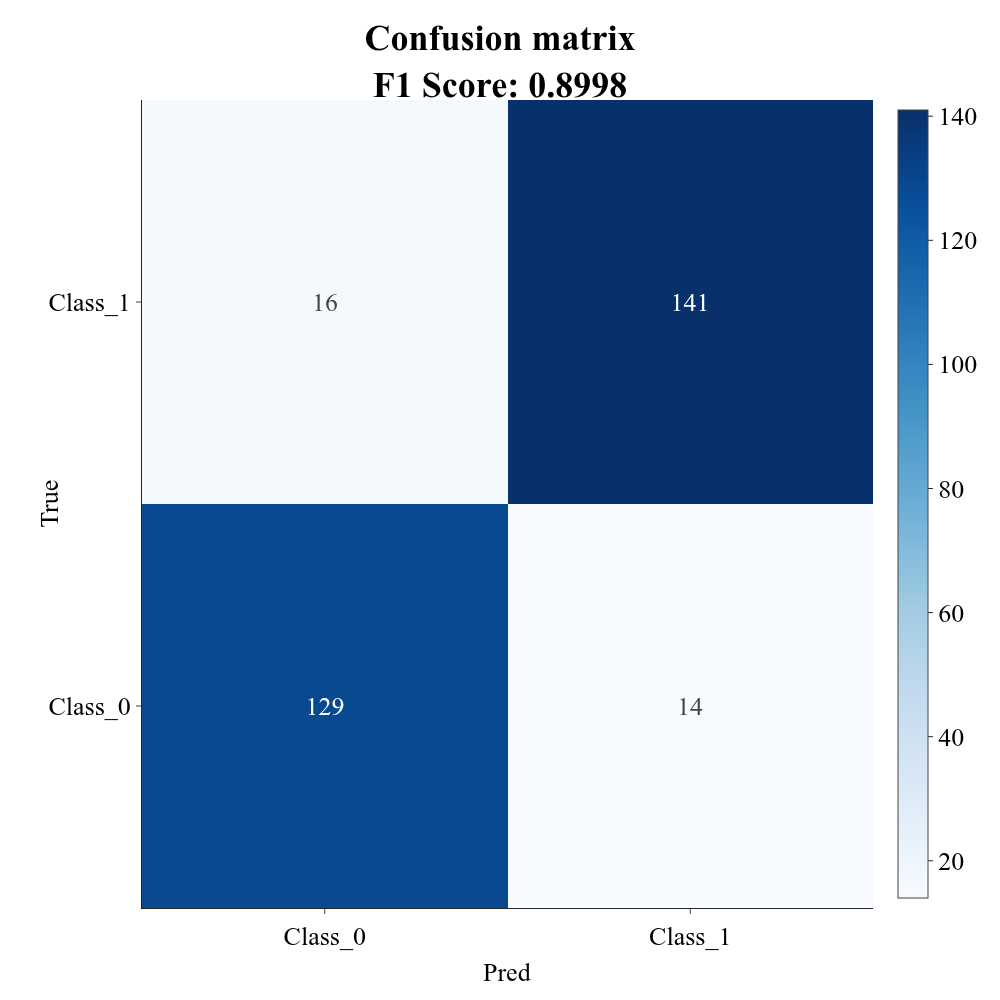

In [5]:
binary_labels = ["Class_0", "Class_1"]
binary_id2label = {i: label for i, label in enumerate(binary_labels)}

class_plots.plot_confusion_matrix(
    y_true=y_binary_test,
    probabilities=probabilities["rf_binary"],
    id2label=binary_id2label,
)

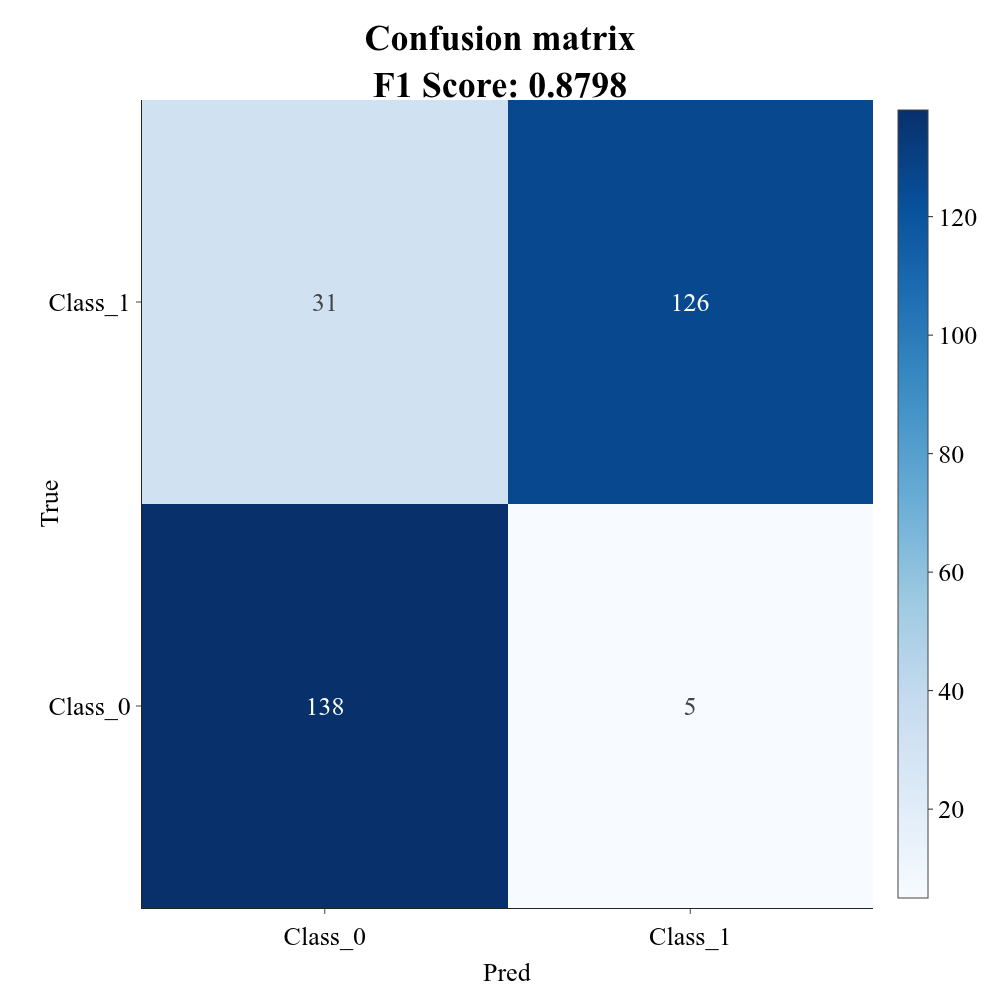

In [6]:
binary_labels = ["Class_0", "Class_1"]
binary_id2label = {i: label for i, label in enumerate(binary_labels)}

class_plots.plot_confusion_matrix(
    y_true=y_binary_test,
    probabilities=probabilities["rf_binary"],
    cutoffs=[0.7],
    id2label=binary_id2label,
)

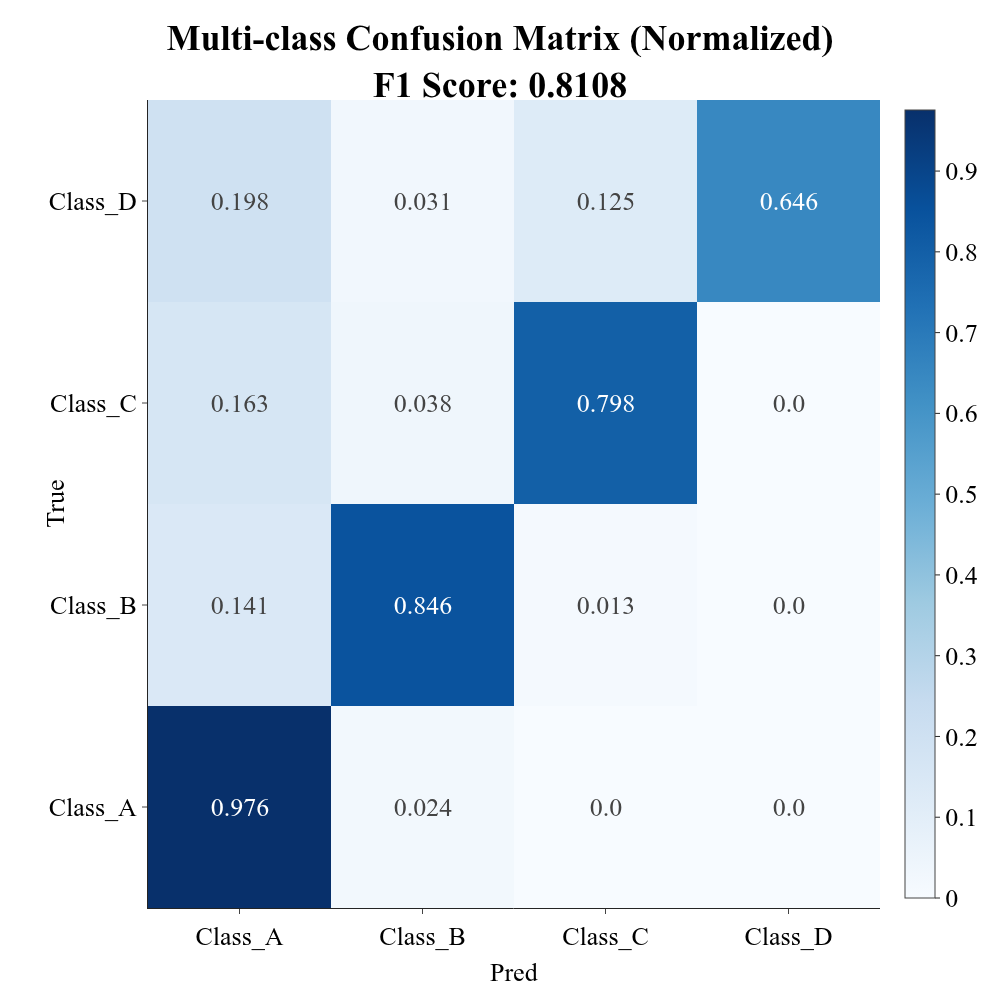

In [7]:
multi_labels = ["Class_A", "Class_B", "Class_C", "Class_D"]
multi_id2label = {i: label for i, label in enumerate(multi_labels)}
multi_cutoffs = np.array([0.2, 0.3, 0.25, 0.35])

class_plots.plot_confusion_matrix(
    y_true=y_multi_test,
    probabilities=probabilities["rf_multi"],
    id2label=multi_id2label,
    cutoffs=multi_cutoffs,
    normalize=True,
    plot_title="Multi-class Confusion Matrix (Normalized)",
)

## 2. subplot_multilabel_conf_matrix() - Confusion Matrix Comparison

This method creates side-by-side confusion matrices comparing predictions with and without custom thresholds. It's particularly useful for understanding the impact of threshold tuning on classification performance.

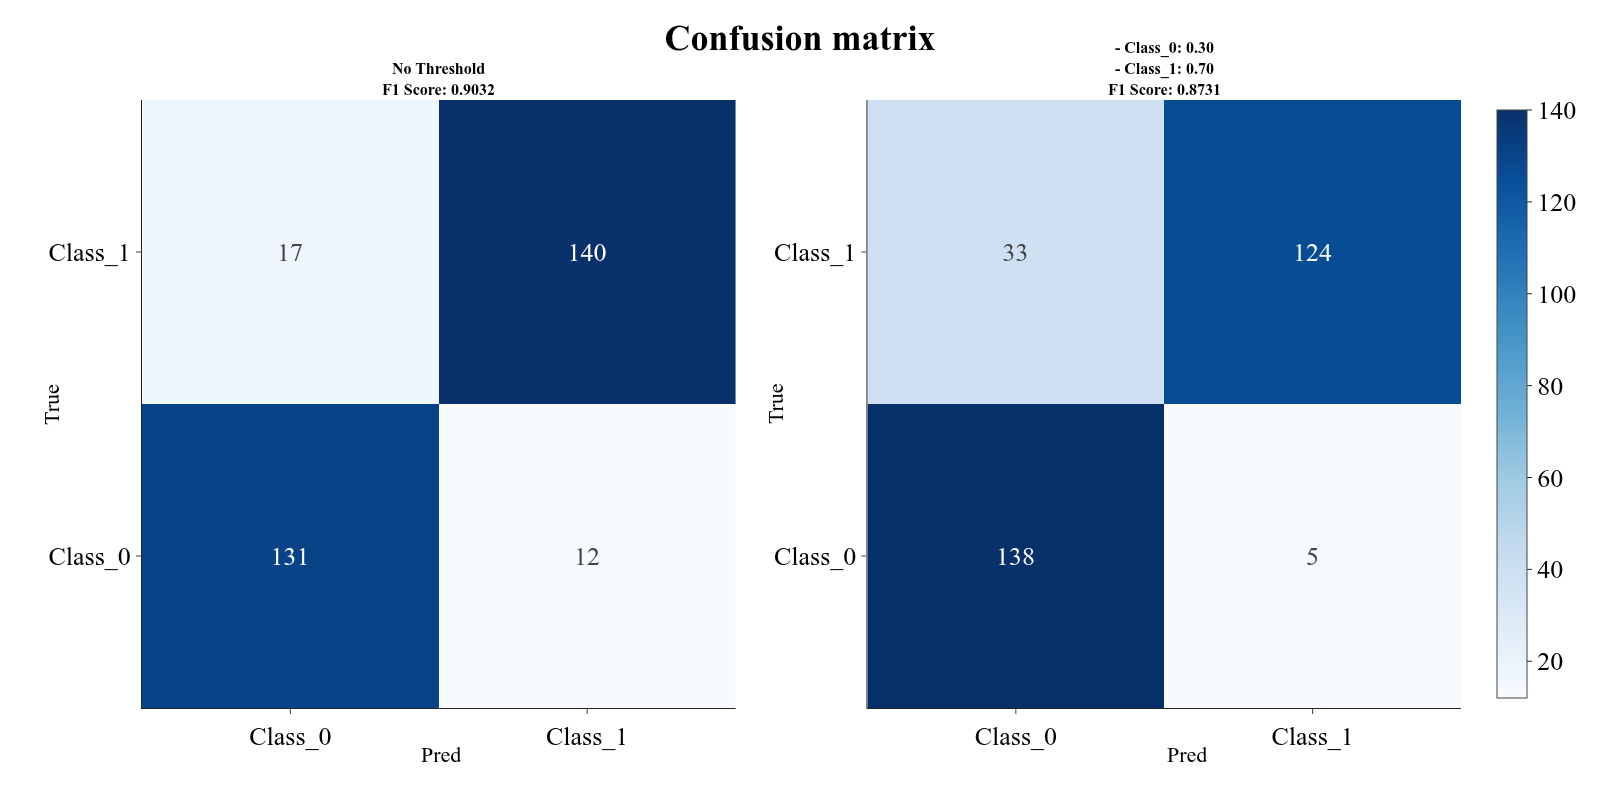

In [8]:
binary_cutoffs = np.array([0.3, 0.7])

class_plots.subplot_multilabel_conf_matrix(
    y_true=y_binary_test,
    probabilities=probabilities["rf_binary"],
    id2label=binary_id2label,
    cutoffs=binary_cutoffs,
    normalize=False,
)

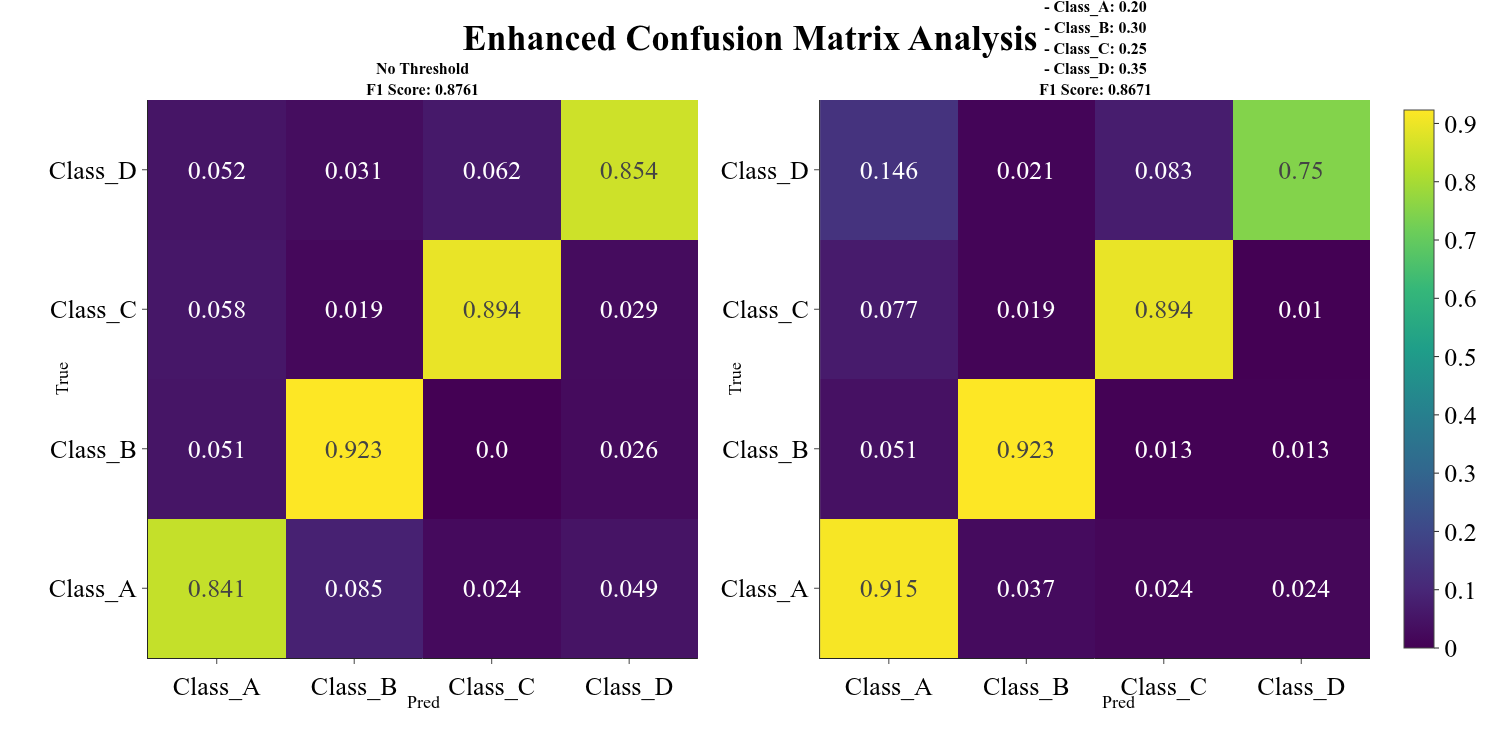

In [9]:
class_plots.subplot_multilabel_conf_matrix(
    y_true=y_multi_test,
    probabilities=probabilities["rf_multi"],
    id2label=multi_id2label,
    cutoffs=multi_cutoffs,
    normalize=True,
    plot_title="Enhanced Confusion Matrix Analysis",
    width=1500,
    height=750,
    colorscale="viridis",
    show_text=True,
    font_size=18,
)

## 2. plot_probabilities_per_class() - Probability Distribution Analysis

This method visualizes the distribution of predicted probabilities for each true class, helping to understand model confidence and calibration. Threshold lines show the impact of custom decision boundaries.

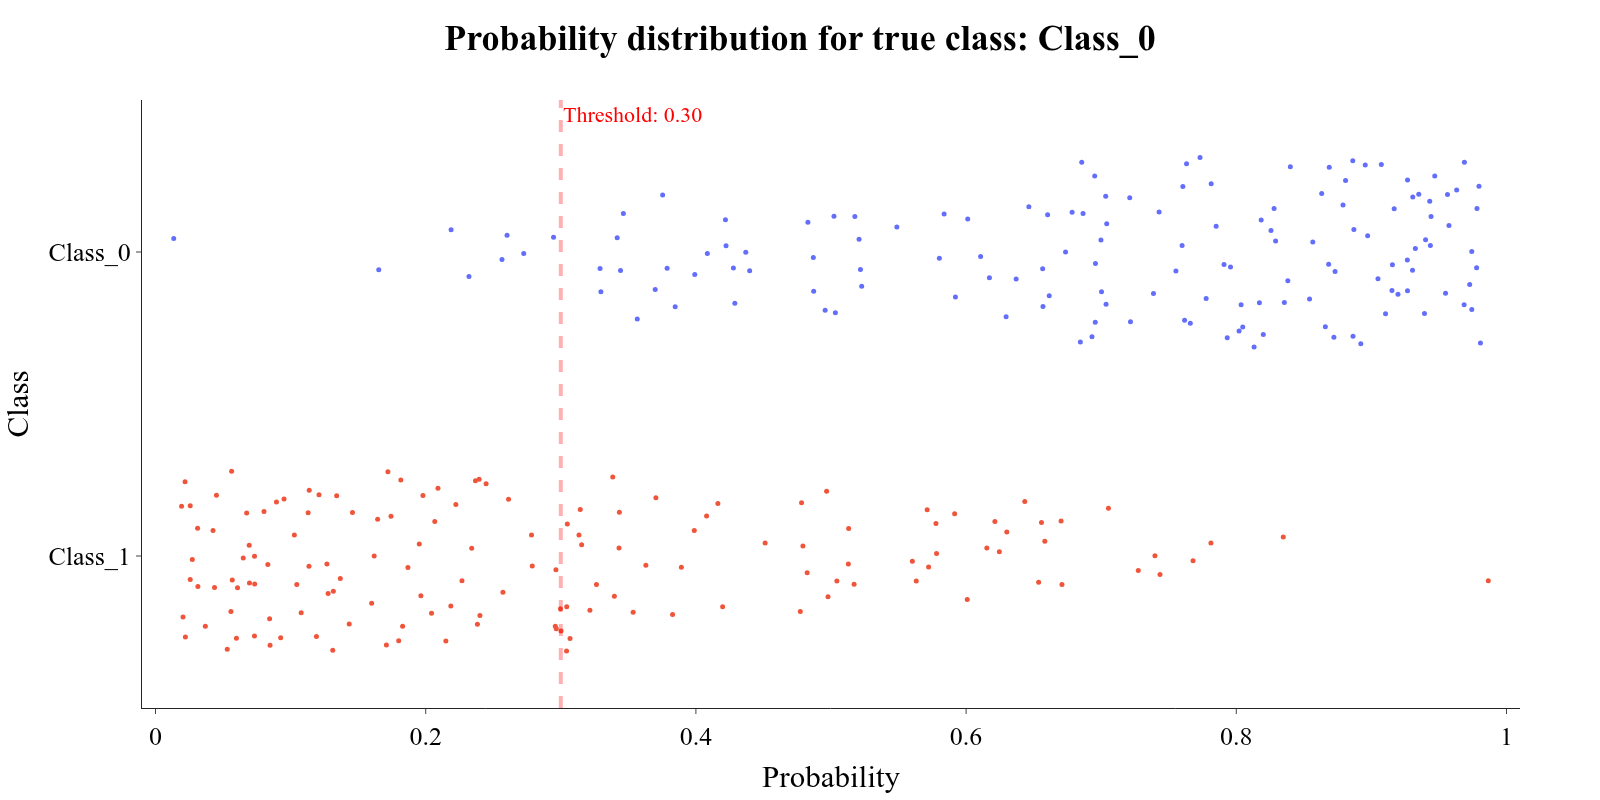

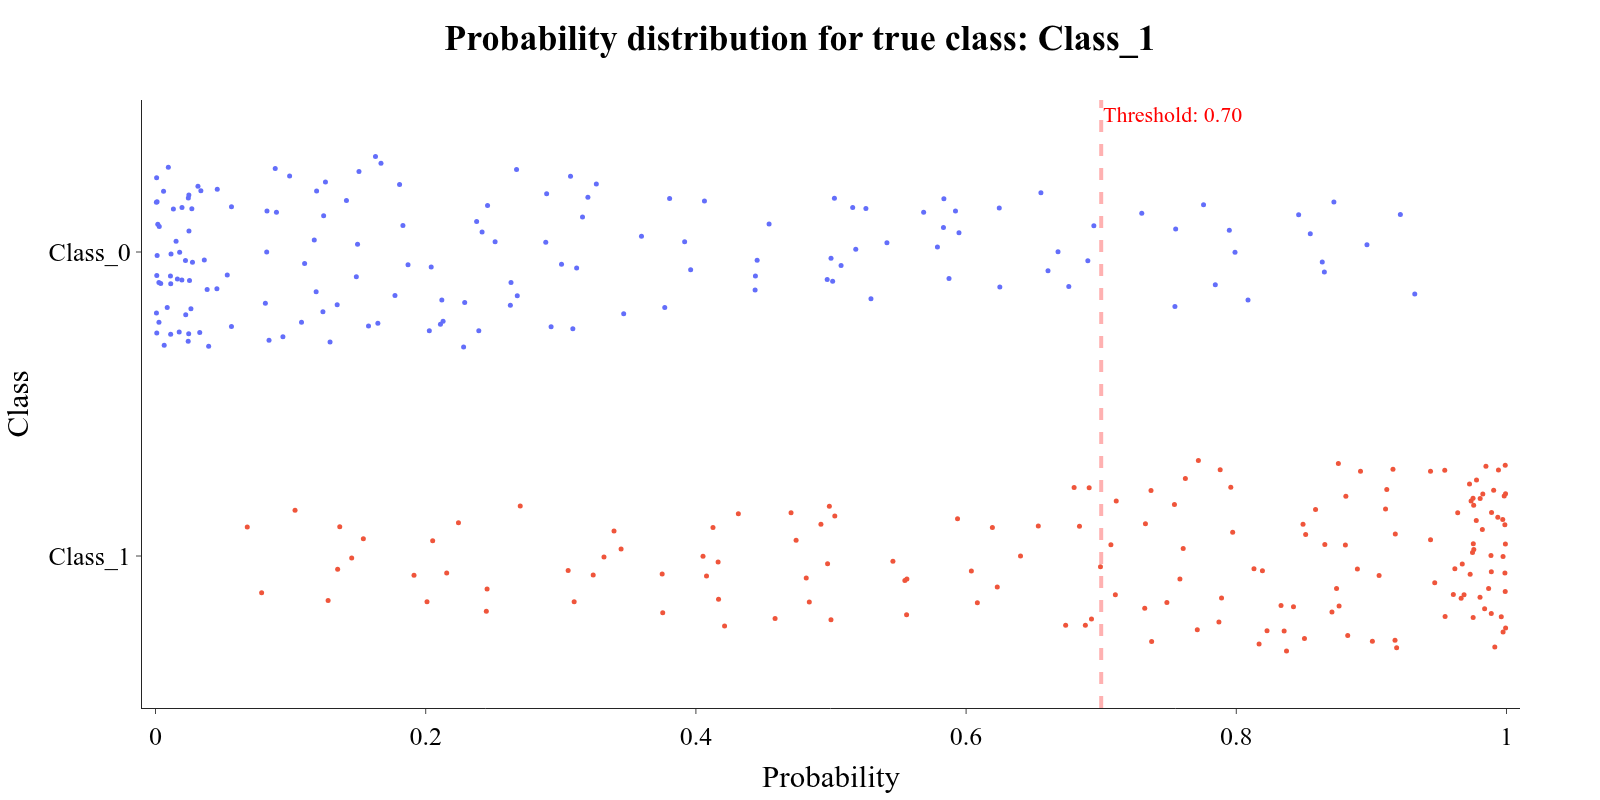

In [10]:
class_plots.plot_probabilities_per_class(
    y_true=y_binary_test,
    probabilities=probabilities["lr_binary"],
    id2label=binary_id2label,
    cutoffs=binary_cutoffs,
)

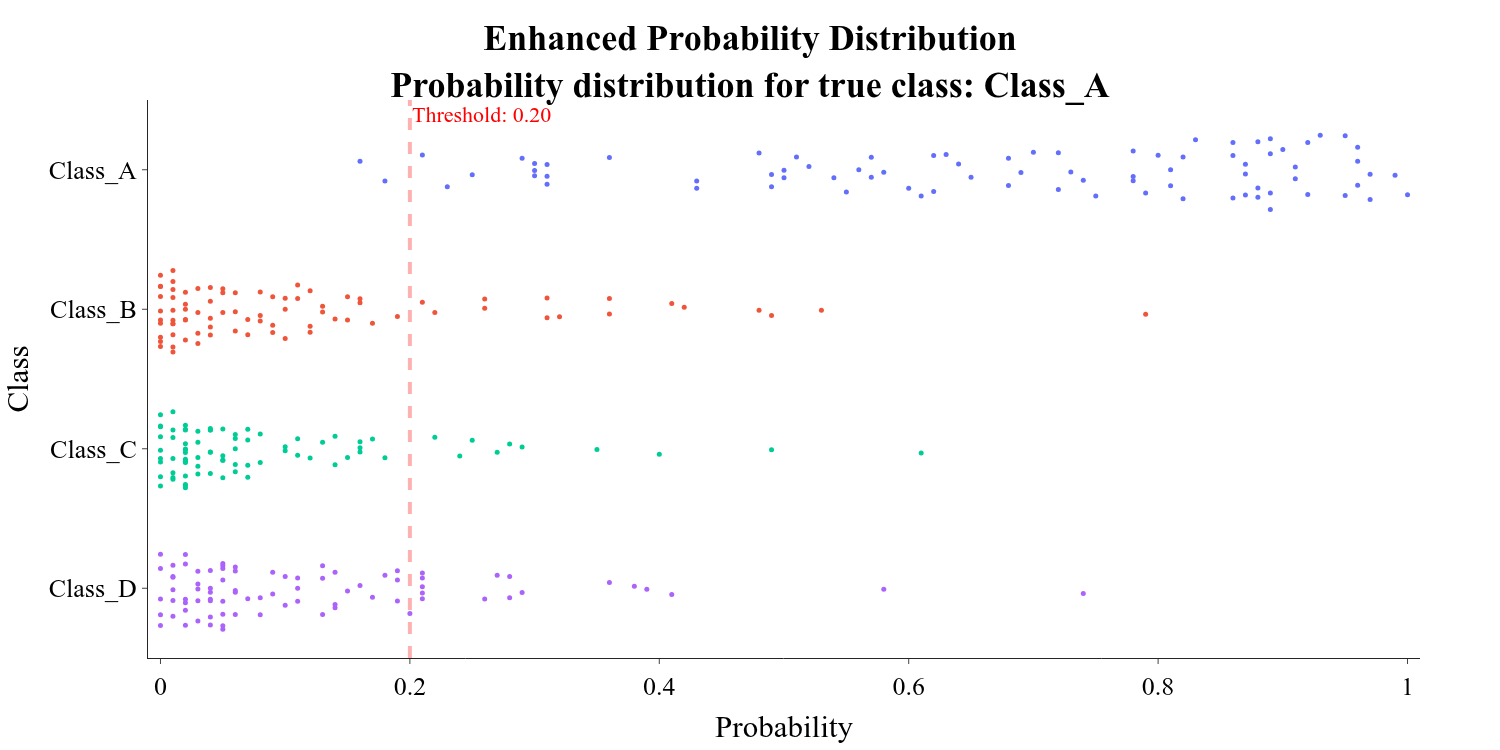

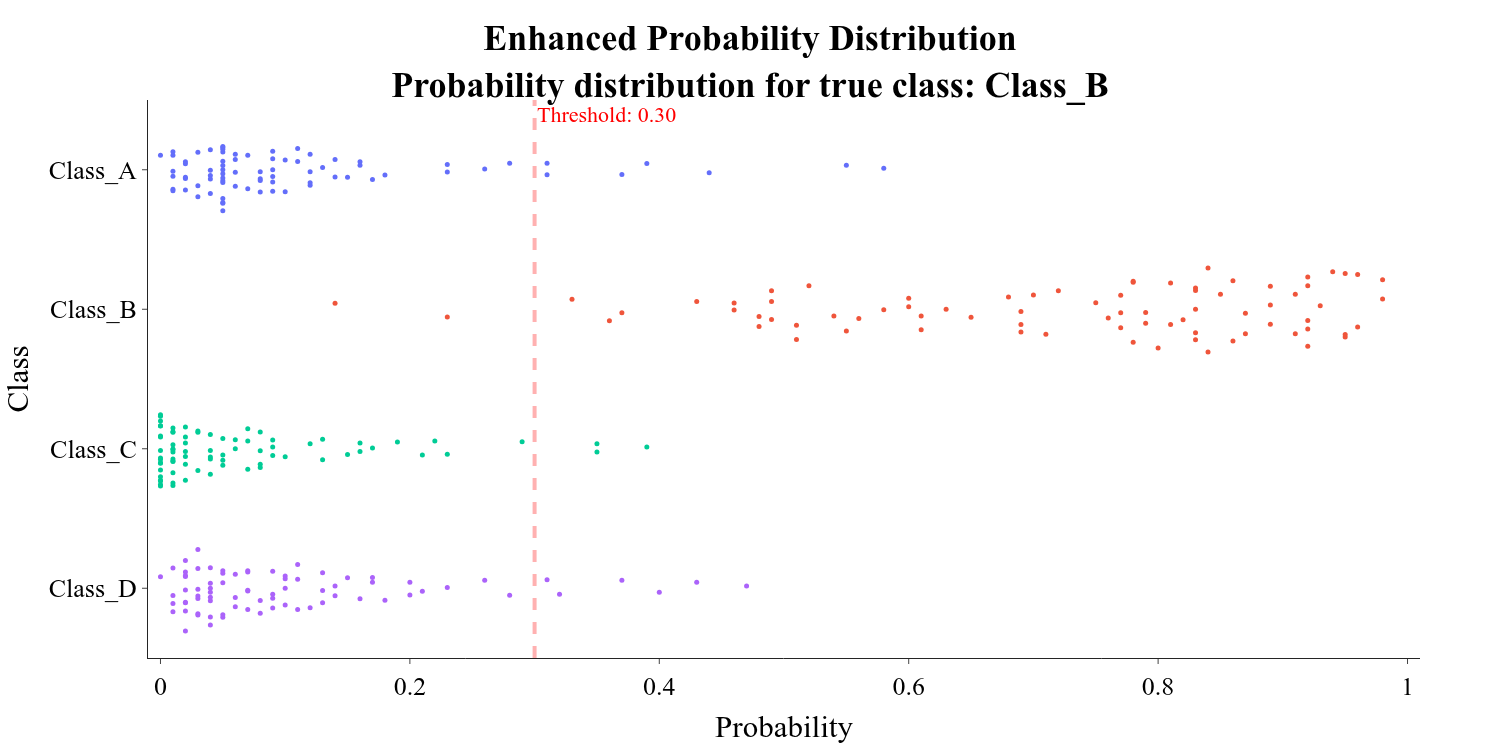

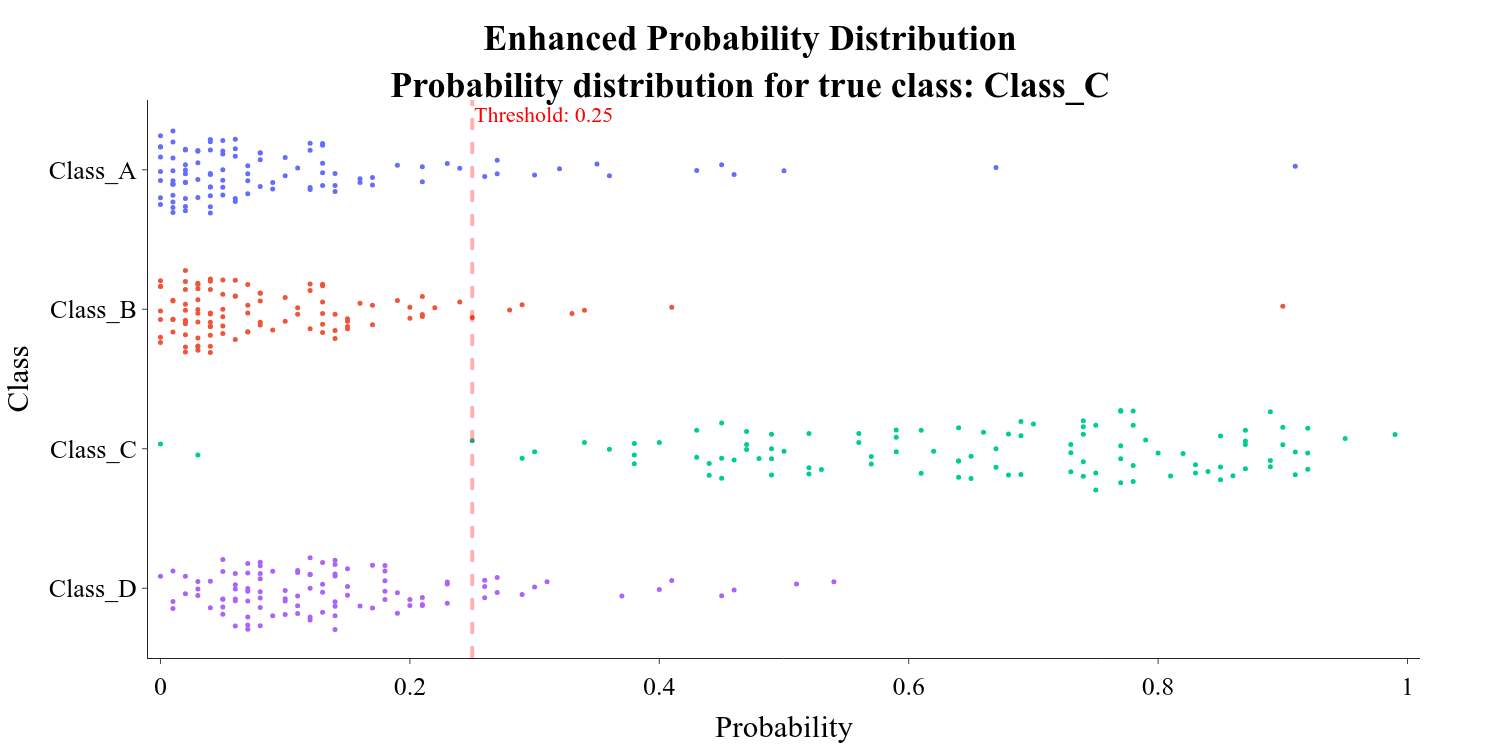

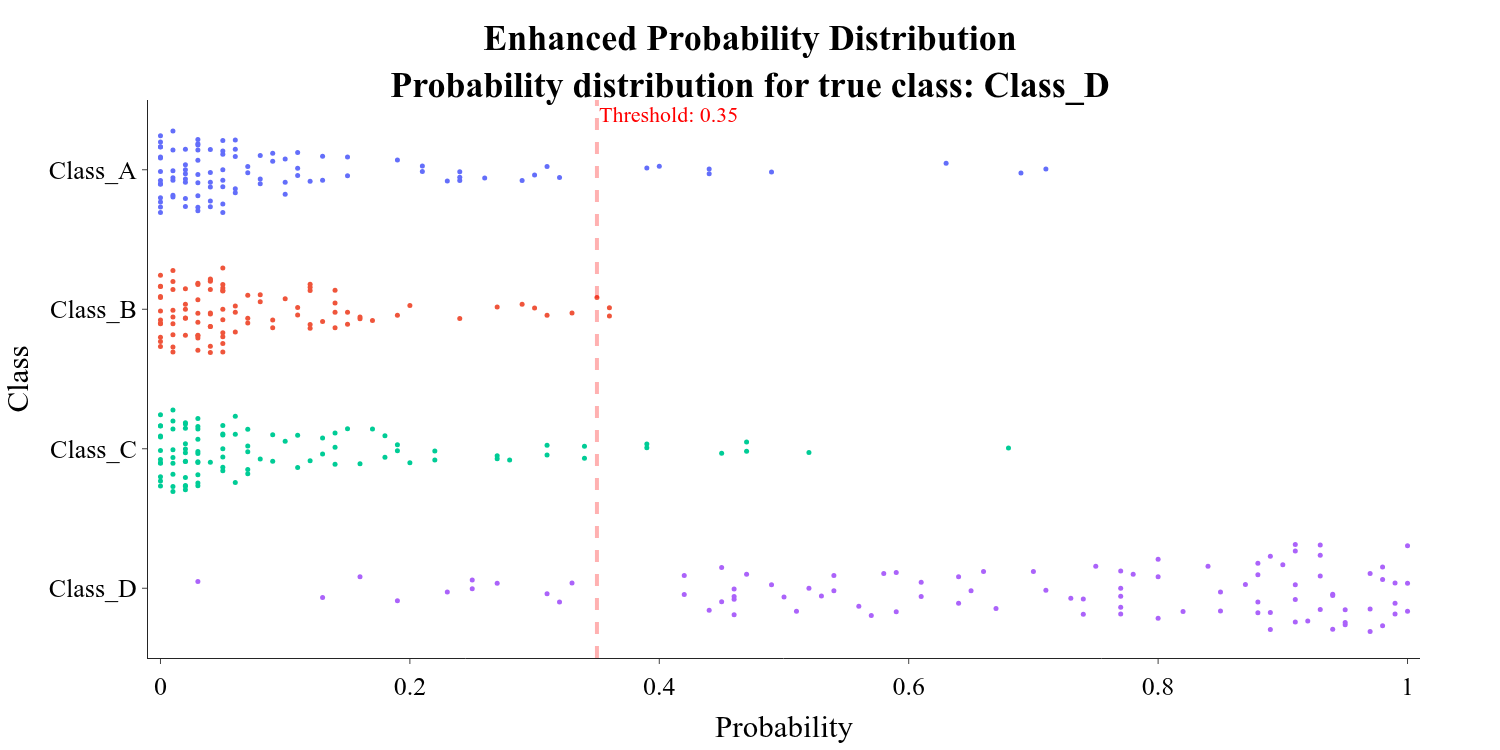

In [11]:
class_plots.plot_probabilities_per_class(
    y_true=y_multi_test,
    probabilities=probabilities["rf_multi"],
    id2label=multi_id2label,
    cutoffs=multi_cutoffs,
    plot_title="Enhanced Probability Distribution",
    width=1500,
    height=750,
)

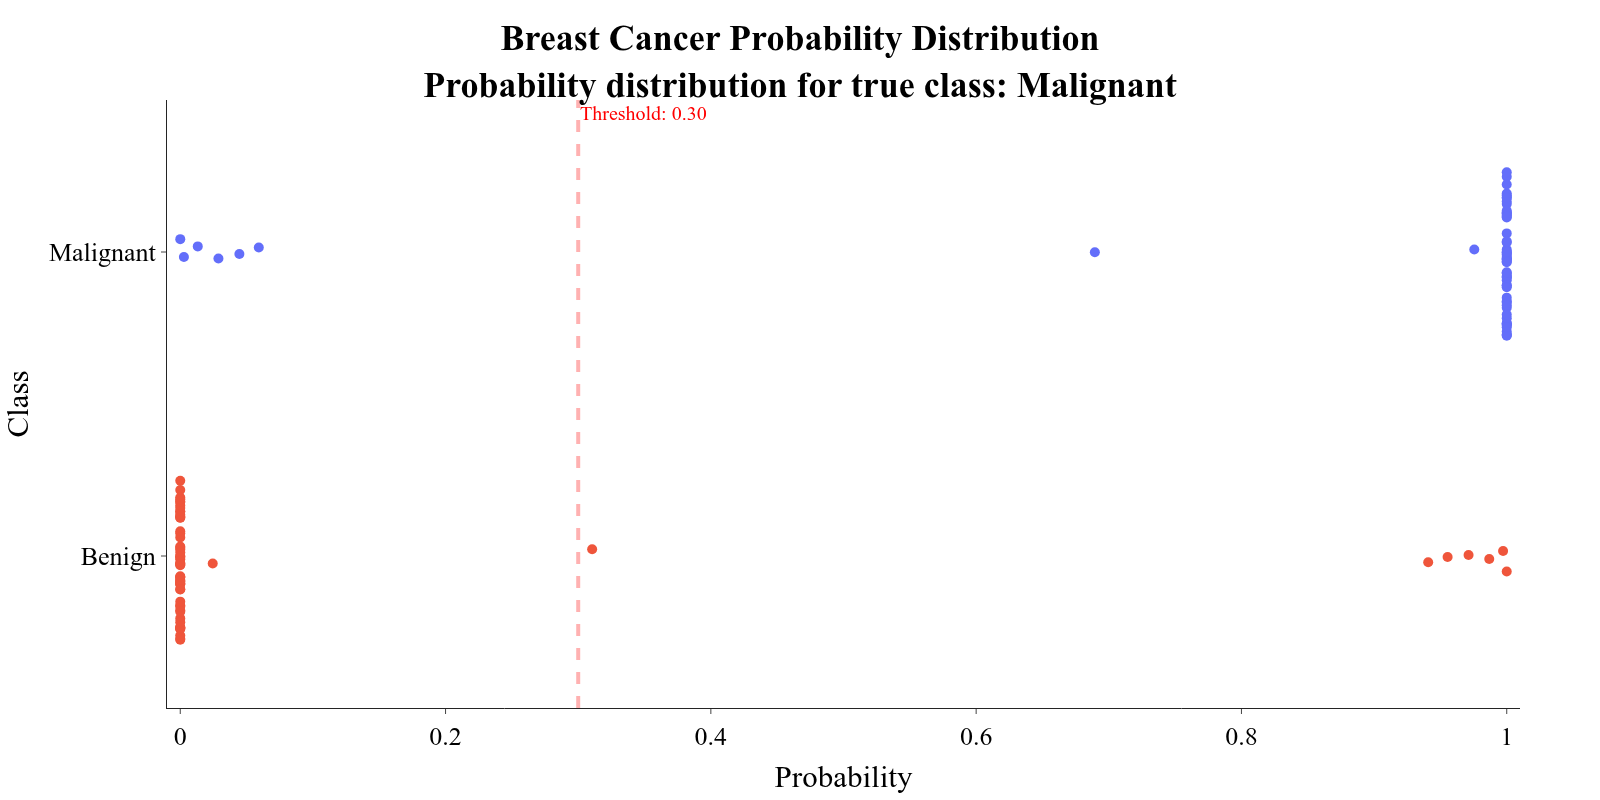

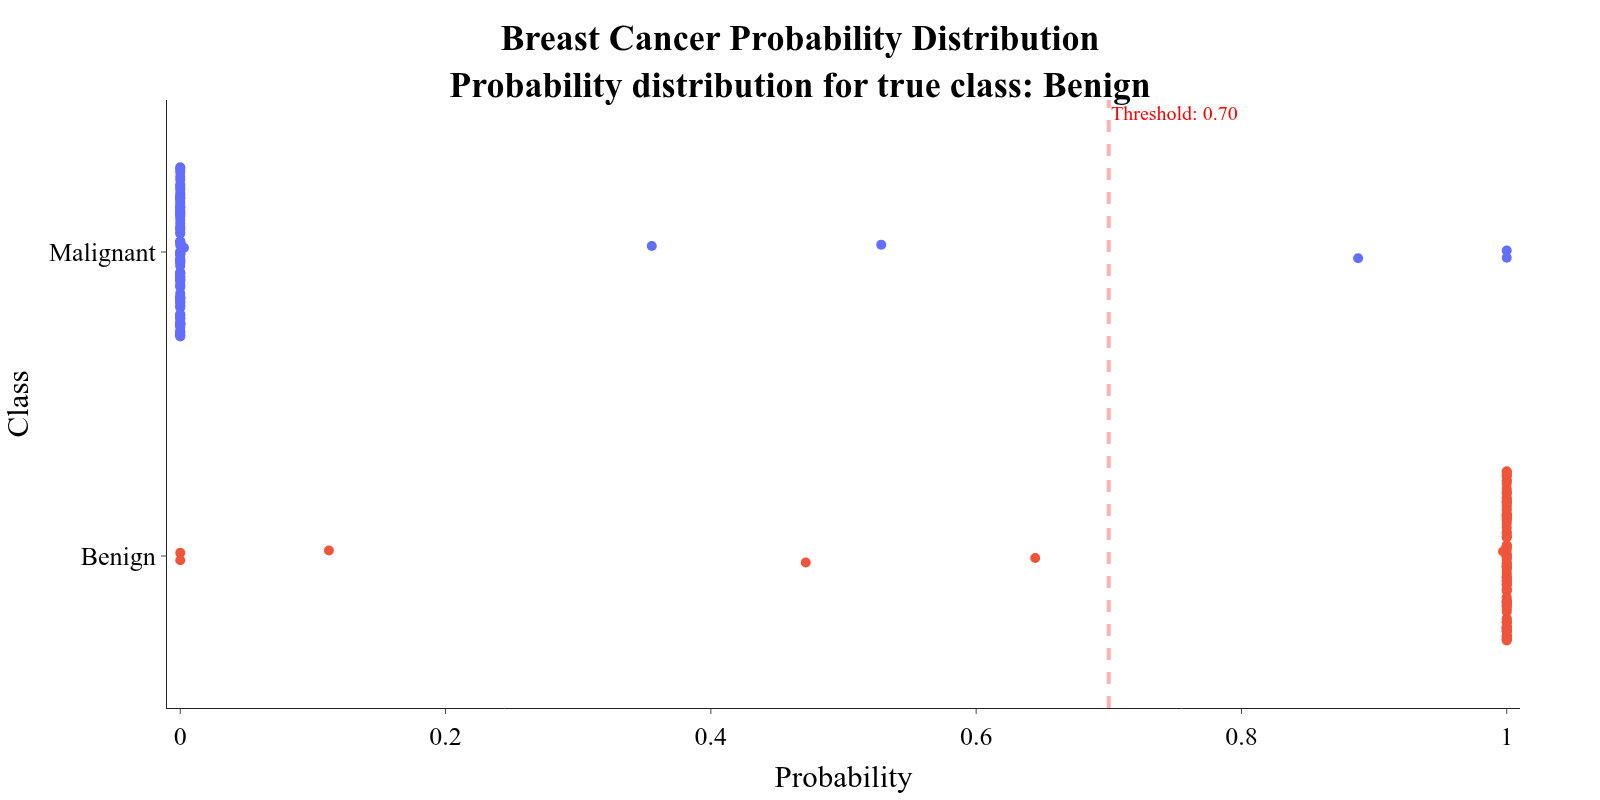

In [12]:
class_plots.plot_probabilities_per_class(
    y_true=y_cancer_test,
    probabilities=probabilities["nb_cancer"],
    id2label={0: "Malignant", 1: "Benign"},
    cutoffs=np.array([0.3, 0.7]),
    plot_title="Breast Cancer Probability Distribution",
    width=1600,
    height=800,
    xaxis_title="Probability",
    yaxis_title="Class",
    threshold_color="red",
    threshold_line_width=4,
    marker_size=10,
    jitter=0.8,
    font_size=20,
)

## 3. roc_auc_multiclass() - ROC Curve Analysis

ROC (Receiver Operating Characteristic) curves visualize the trade-off between true positive rate and false positive rate. This method supports both binary and multi-class scenarios.

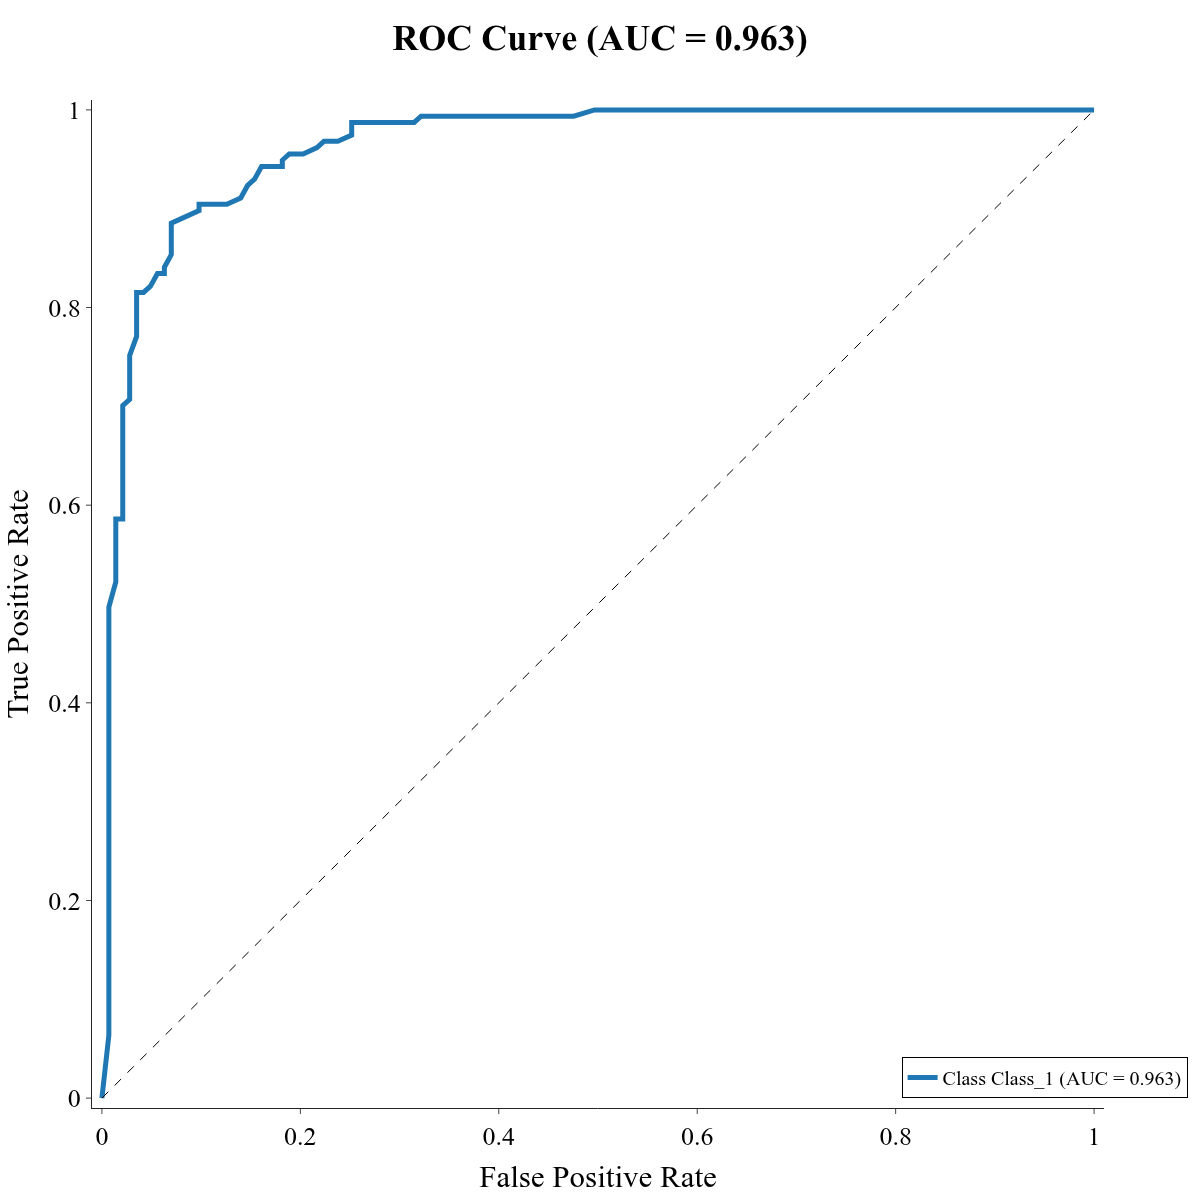

In [13]:
class_plots.plot_roc_auc(
    y_true=y_binary_test,
    probabilities=probabilities["rf_binary"],
    id2label=binary_id2label,
)

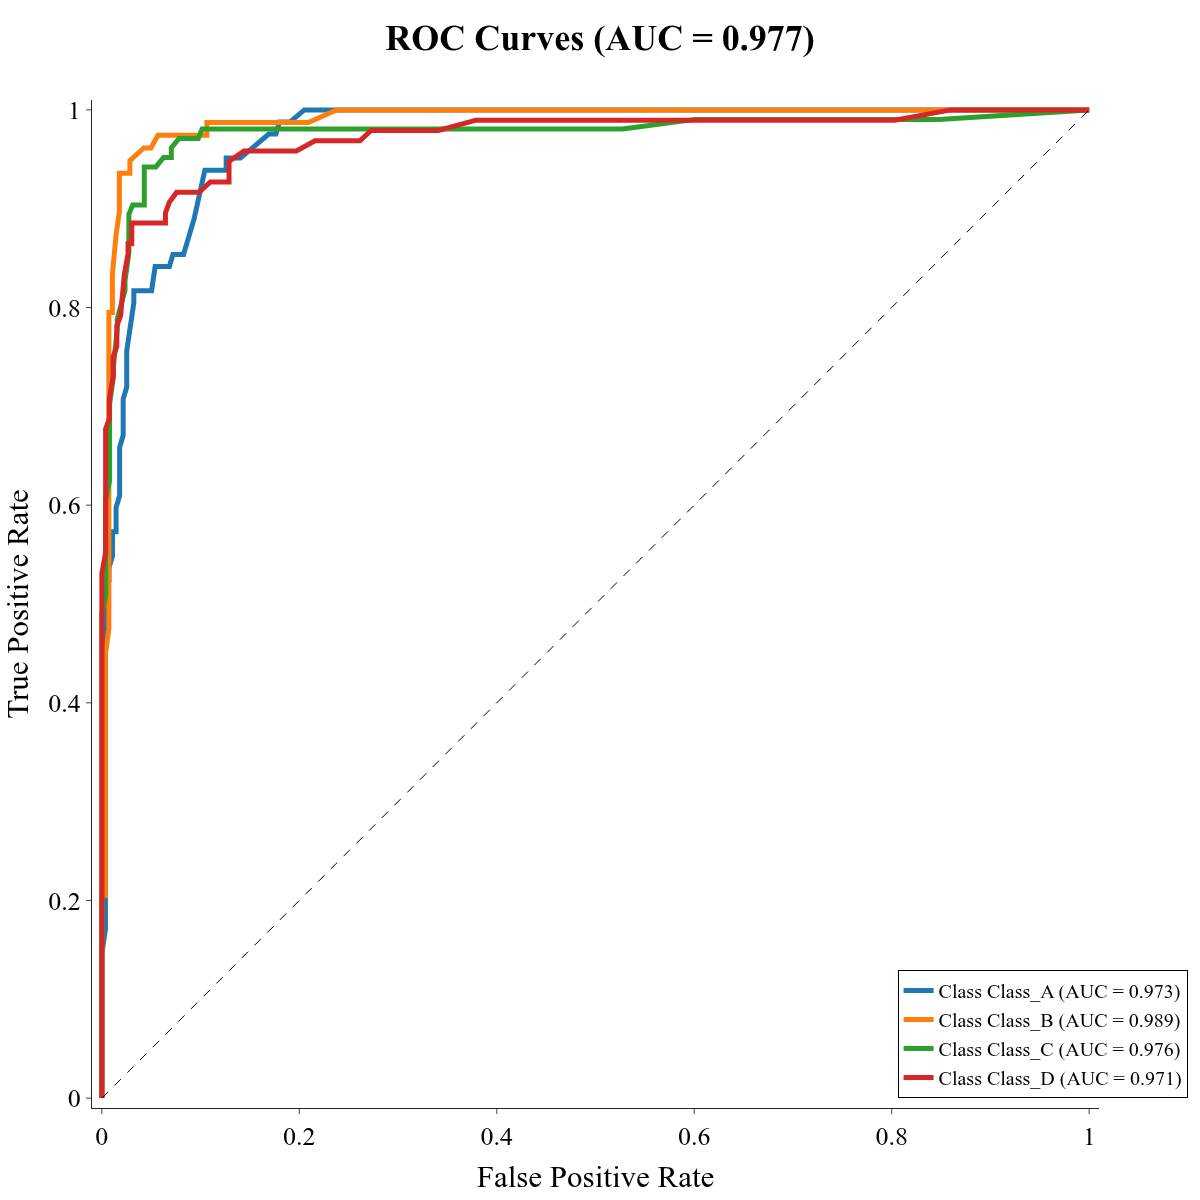

In [14]:
class_plots.plot_roc_auc(
    y_true=y_multi_test,
    probabilities=probabilities["rf_multi"],
    id2label=multi_id2label,
)

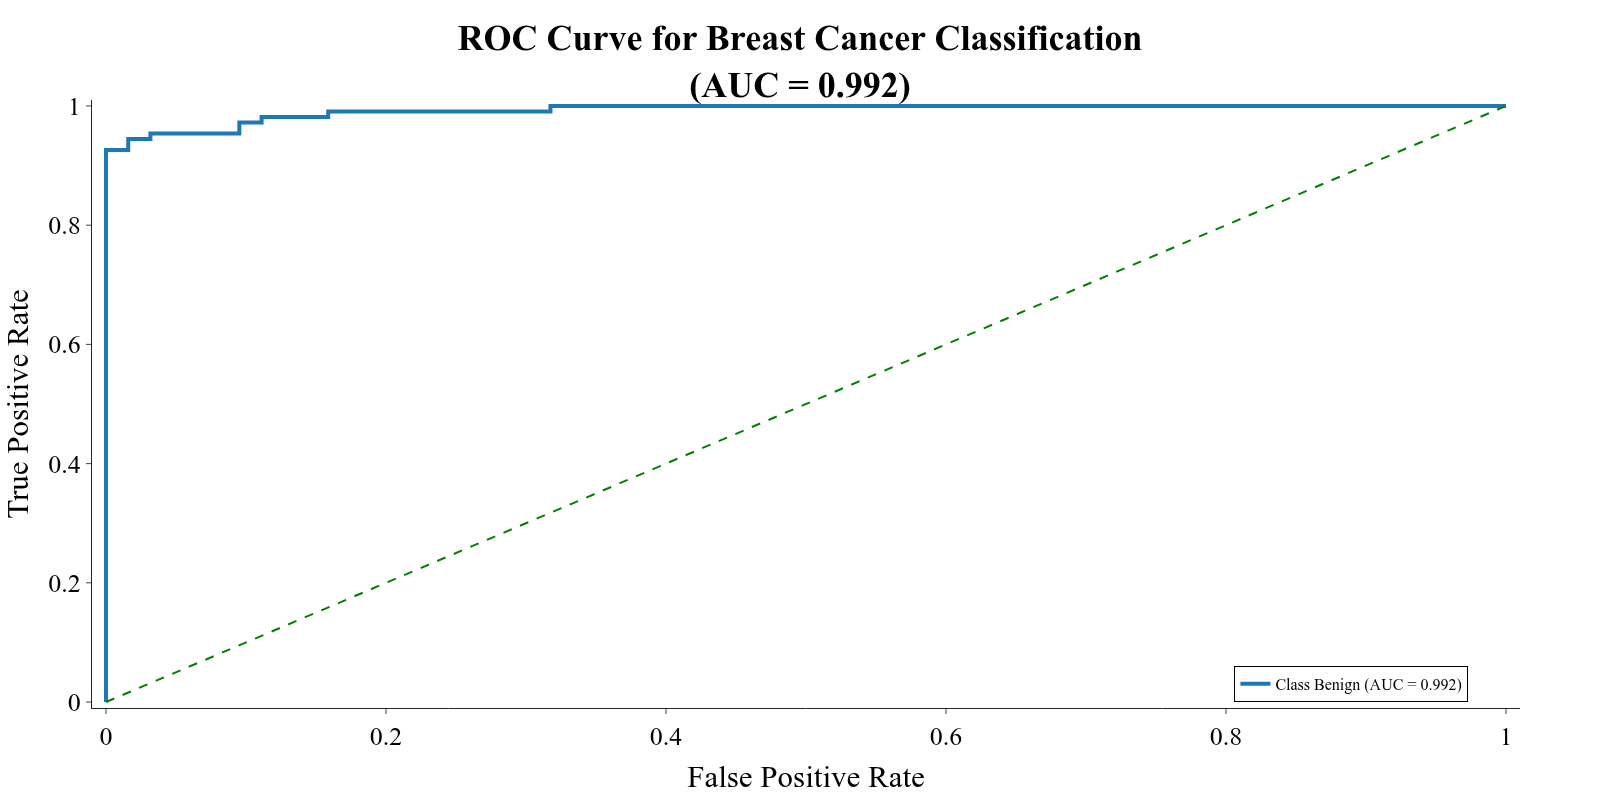

In [15]:
class_plots.plot_roc_auc(
    y_true=y_cancer_test,
    probabilities=probabilities["nb_cancer"],
    id2label={0: "Malignant", 1: "Benign"},
    plot_title="ROC Curve for Breast Cancer Classification",
    width=1600,
    height=800,
    xaxis_title="False Positive Rate",
    yaxis_title="True Positive Rate",
    random_line_color="green",
    random_line_width=2,
    font_size=18,
    line_width=4,
)